In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from glob import glob
from collections import defaultdict

num_classes = 4  
# subject_pixel_counts = defaultdict(lambda: np.zeros(num_classes))

def pixel_distribution(image_paths):
    
    subject_pixel_counts = defaultdict(lambda: np.zeros(num_classes))

    label_files = sorted(glob(os.path.join(image_paths, "*.png")))
    
    for label_file in label_files:
        subj_name = os.path.basename(label_file)
        subj_name = os.path.splitext(subj_name)[0]
        if subj_name.startswith('p'):
            subj_name = subj_name[1:]

        # print(f"Processing {subj_name}...")
    
        label_img = np.array(Image.open(label_file))
        unique, counts = np.unique(label_img, return_counts=True)
        
        label_distribution = dict(zip(unique, counts))

        for c in range(4):
            subject_pixel_counts[subj_name][c] += label_distribution.get(c, 0)

    class_names = ['Background', 'Cornea', 'Lens', 'Nucleus']

    df_counts = pd.DataFrame.from_dict(
        subject_pixel_counts,
        orient='index',
        columns=class_names
    )

    df_dist = df_counts.div(df_counts.sum(axis=1), axis=0)

    mean_dist = df_dist.mean()
    std_dist = df_dist.std()

    summary = pd.DataFrame({
        'Mean': mean_dist,
        'Std': std_dist
    })

    # print(summary)

    return df_dist, df_counts, summary
    

In [9]:
fuzzy_data = "fuzzy data"
normal_data = "Normal data"
fuzzy_data2 = "labels"
print('data paths:', fuzzy_data2, normal_data)

fuzzy_dist, fuzzy_counts, fuzzy_summary = pixel_distribution(fuzzy_data2)
normal_dist, normal_counts, normal_summary = pixel_distribution(normal_data)

# fuzzy_dist.to_excel("fuzzy_data_distribution.xlsx")
# normal_dist.to_excel("normal_data_distribution.xlsx")
# fuzzy_counts.to_excel("fuzzy_data_counts.xlsx")
# normal_counts.to_excel("normal_data_counts.xlsx")

print("Fuzzy Data Summary:")
print(fuzzy_summary)
print("\nNormal Data Summary:")
print(normal_summary)
# # fuzzy_dist
# # fuzzy_counts

data paths: labels Normal data
Fuzzy Data Summary:
                Mean       Std
Background  0.743647  0.019662
Cornea      0.037904  0.002732
Lens        0.117014  0.013839
Nucleus     0.101435  0.013204

Normal Data Summary:
                Mean       Std
Background  0.748949  0.019566
Cornea      0.035214  0.002052
Lens        0.116968  0.013591
Nucleus     0.098868  0.012900


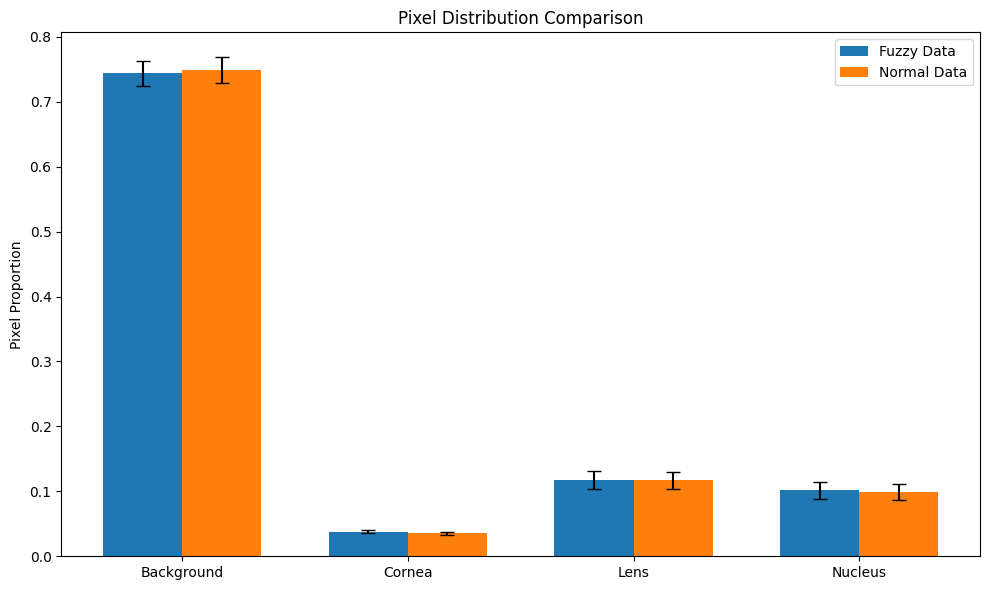

In [10]:
plt.figure(figsize=(10, 6))
class_names = ['Background', 'Cornea', 'Lens', 'Nucleus']
# class_names = ['Cornea', 'Lens', 'Nucleus']
x = np.arange(len(class_names))
width = 0.35
fuzzy_means = fuzzy_summary['Mean']
fuzzy_stds = fuzzy_summary['Std']
normal_means = normal_summary['Mean']
normal_stds = normal_summary['Std']
plt.bar(x - width/2, fuzzy_means, width, yerr=fuzzy_stds, label='Fuzzy Data', capsize=5)
plt.bar(x + width/2, normal_means, width, yerr=normal_stds, label='Normal Data', capsize=5)
plt.xticks(x, class_names)
plt.ylabel('Pixel Proportion')
plt.title('Pixel Distribution Comparison')
plt.legend()
plt.tight_layout()
plt.show()

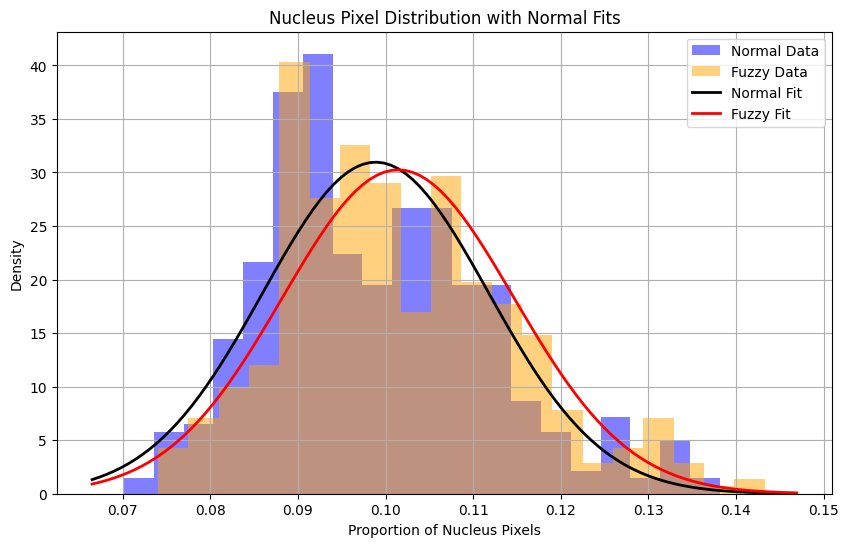

In [11]:
plt.figure(figsize=(10, 6))
normal_dist['Nucleus'].hist(bins=20, alpha=0.5, label='Normal Data', color='blue', density=True)
fuzzy_dist['Nucleus'].hist(bins=20, alpha=0.5, label='Fuzzy Data', color='orange', density=True)
mu_normal, std_normal = norm.fit(normal_dist['Nucleus'])
mu_fuzzy, std_fuzzy = norm.fit(fuzzy_dist['Nucleus'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_normal = norm.pdf(x, mu_normal, std_normal)
p_fuzzy = norm.pdf(x, mu_fuzzy, std_fuzzy)
plt.plot(x, p_normal, 'k', linewidth=2, label='Normal Fit')
plt.plot(x, p_fuzzy, 'r', linewidth=2, label='Fuzzy Fit')
plt.title('Nucleus Pixel Distribution with Normal Fits')
plt.xlabel('Proportion of Nucleus Pixels')
plt.ylabel('Density')
plt.legend()
plt.show()

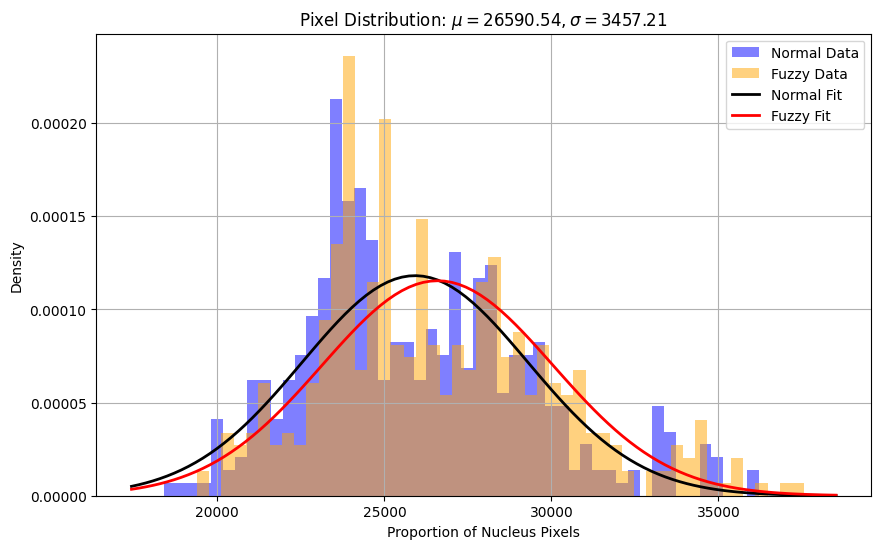

In [12]:
plt.figure(figsize=(10, 6))
normal_counts['Nucleus'].hist(bins=50, alpha=0.5, label='Normal Data', color='blue', density=True)
fuzzy_counts['Nucleus'].hist(bins=50, alpha=0.5, label='Fuzzy Data', color='orange', density=True)
mu_normal, std_normal = norm.fit(normal_counts['Nucleus'])
mu_fuzzy, std_fuzzy = norm.fit(fuzzy_counts['Nucleus'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_normal = norm.pdf(x, mu_normal, std_normal)
p_fuzzy = norm.pdf(x, mu_fuzzy, std_fuzzy)
plt.plot(x, p_normal, 'k', linewidth=2, label='Normal Fit')
plt.plot(x, p_fuzzy, 'r', linewidth=2, label='Fuzzy Fit')
plt.title('Pixel Distribution: $\\mu={:.2f}, \\sigma={:.2f}$'.format(mu_fuzzy, std_fuzzy))
plt.xlabel('Proportion of Nucleus Pixels')
plt.ylabel('Density')
plt.legend()
plt.show()

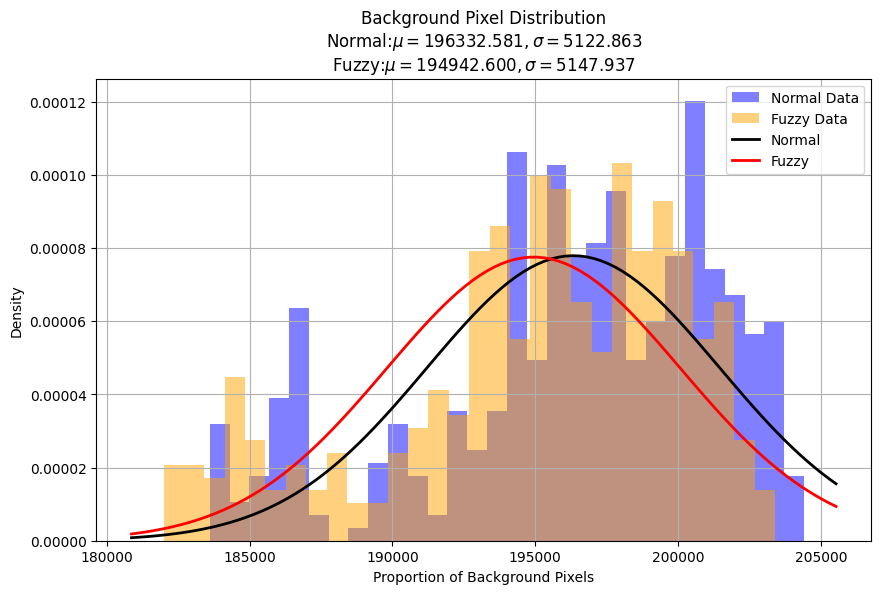

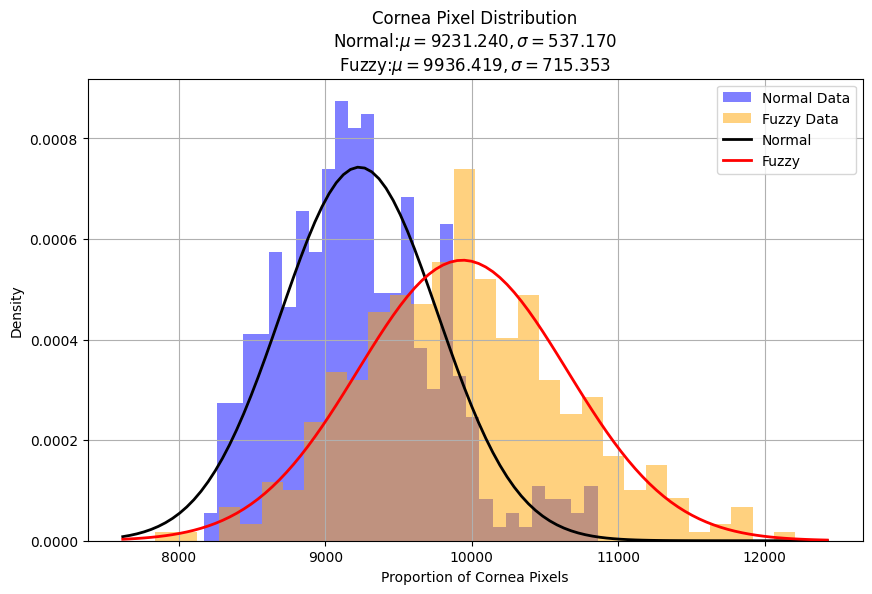

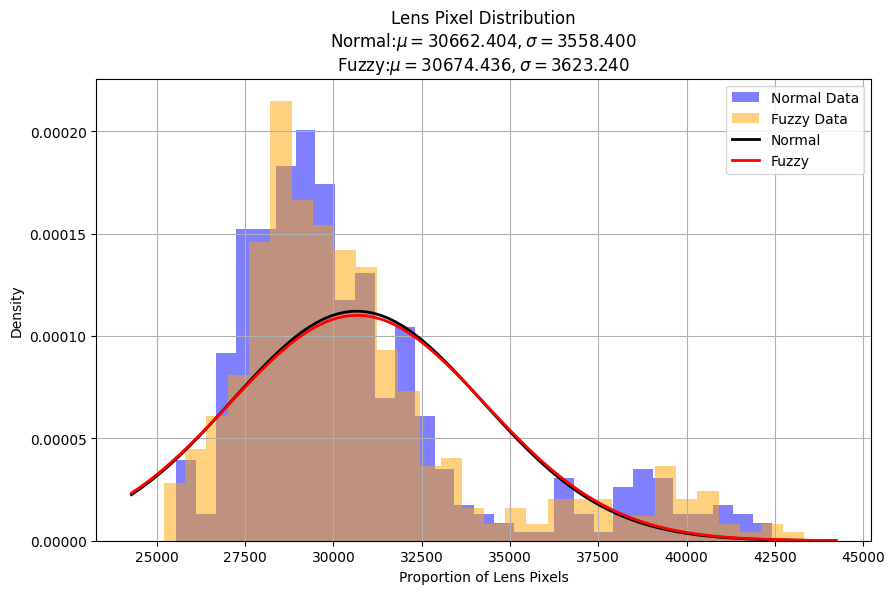

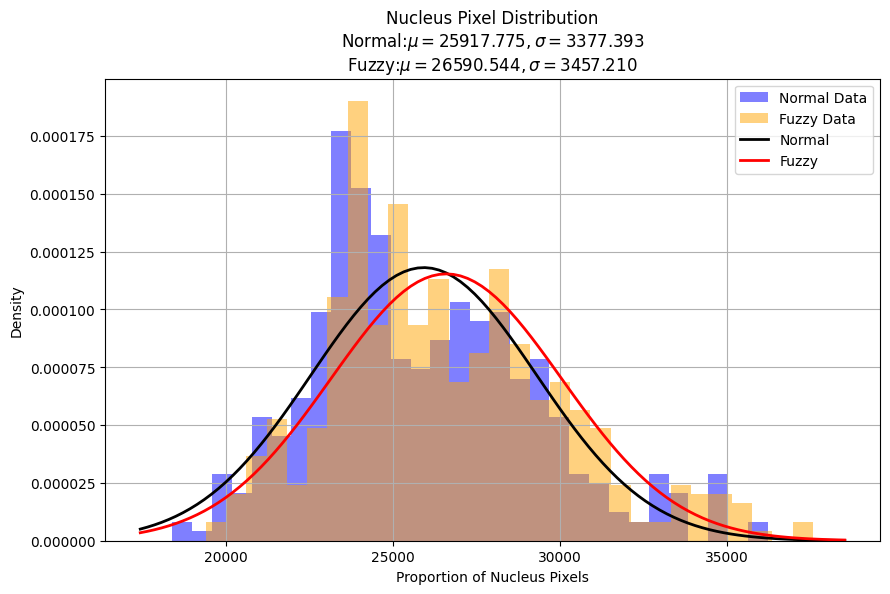

In [13]:
for class_name in class_names:
    plt.figure(figsize=(10, 6))
    normal_counts[class_name].hist(bins=30, alpha=0.5, label='Normal Data', color='blue', density=True)
    fuzzy_counts[class_name].hist(bins=30, alpha=0.5, label='Fuzzy Data', color='orange', density=True)
    mu_normal, std_normal = norm.fit(normal_counts[class_name])
    mu_fuzzy, std_fuzzy = norm.fit(fuzzy_counts[class_name])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p_normal = norm.pdf(x, mu_normal, std_normal)
    p_fuzzy = norm.pdf(x, mu_fuzzy, std_fuzzy)
    plt.plot(x, p_normal, 'k', linewidth=2, label='Normal')
    plt.plot(x, p_fuzzy, 'r', linewidth=2, label='Fuzzy')
    plt.title(f'{class_name} Pixel Distribution\n'
              f'Normal:$\\mu={mu_normal:.3f}, \\sigma={std_normal:.3f}$\n'
              f'Fuzzy:$\\mu={mu_fuzzy:.3f}, \\sigma={std_fuzzy:.3f}$')
    # plt.title('Pixel Distribution: $\\mu={:.2f}, \\sigma={:.2f}$'.format(mu_fuzzy, std_fuzzy))
    plt.xlabel(f'Proportion of {class_name} Pixels')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

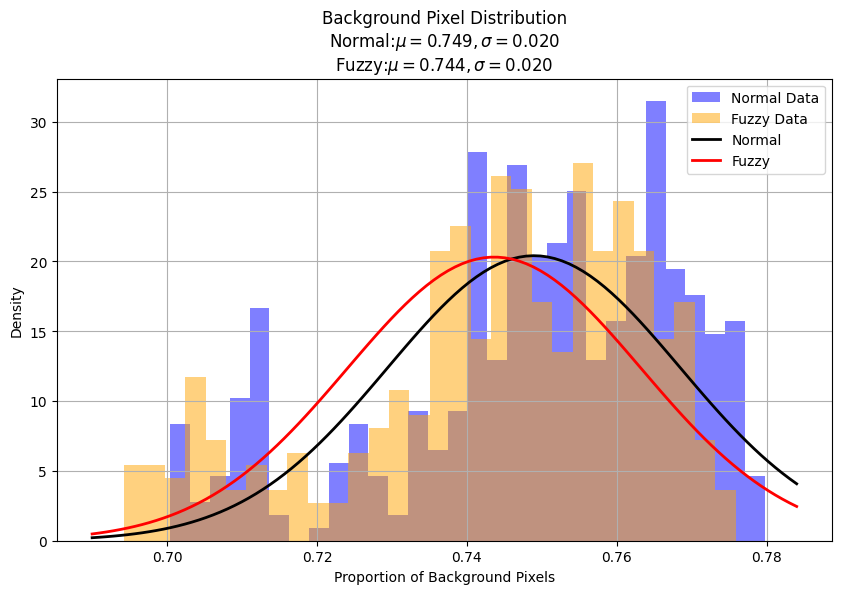

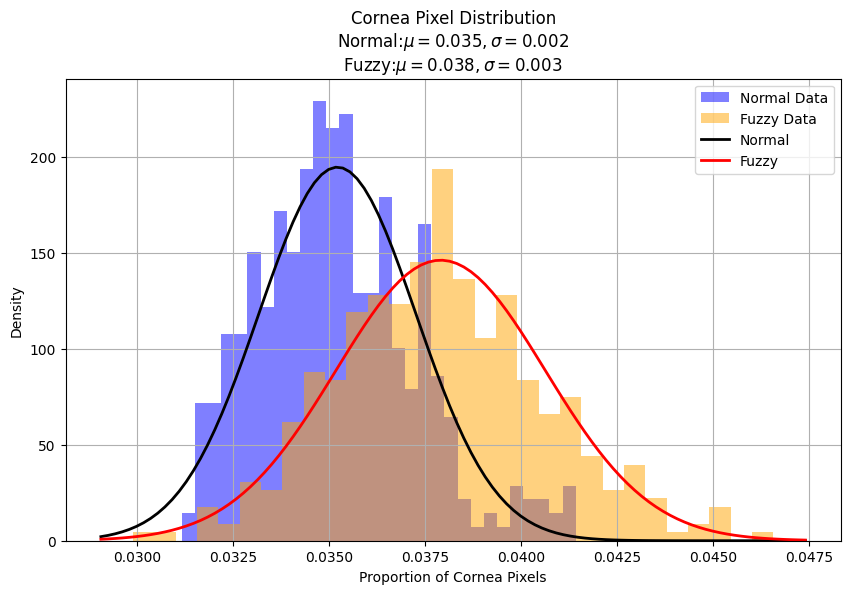

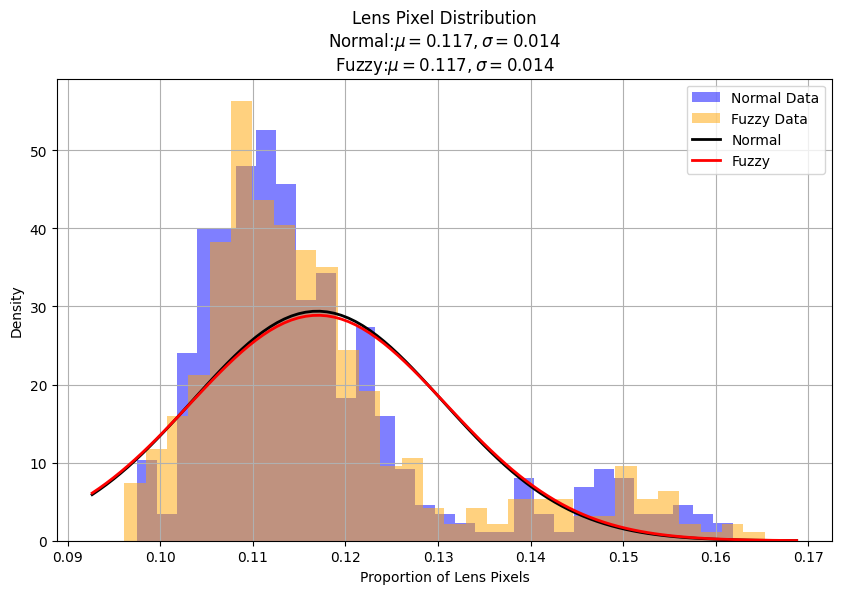

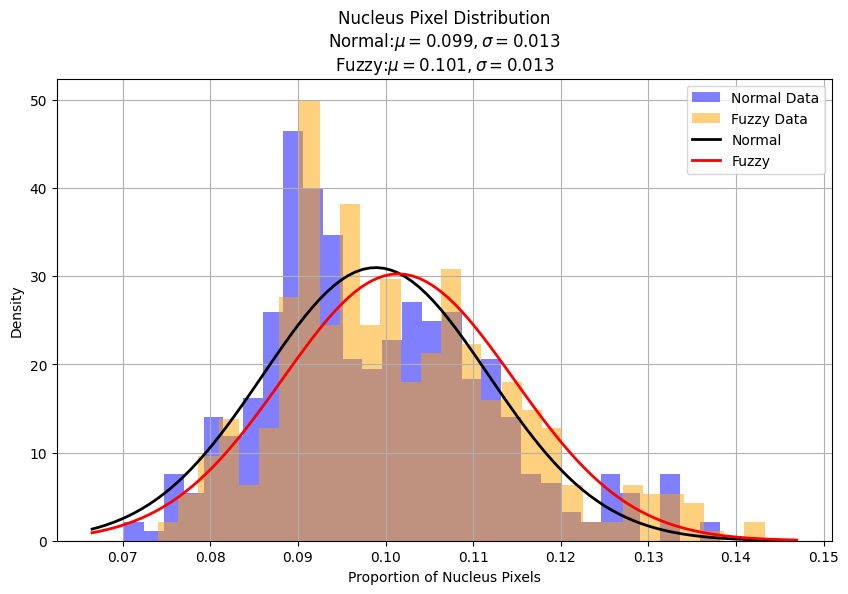

In [14]:
for class_name in class_names:
    plt.figure(figsize=(10, 6))
    normal_dist[class_name].hist(bins=30, alpha=0.5, label='Normal Data', color='blue', density=True)
    fuzzy_dist[class_name].hist(bins=30, alpha=0.5, label='Fuzzy Data', color='orange', density=True)
    mu_normal, std_normal = norm.fit(normal_dist[class_name])
    mu_fuzzy, std_fuzzy = norm.fit(fuzzy_dist[class_name])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p_normal = norm.pdf(x, mu_normal, std_normal)
    p_fuzzy = norm.pdf(x, mu_fuzzy, std_fuzzy)
    plt.plot(x, p_normal, 'k', linewidth=2, label='Normal')
    plt.plot(x, p_fuzzy, 'r', linewidth=2, label='Fuzzy')
    plt.title(f'{class_name} Pixel Distribution\n'
              f'Normal:$\\mu={mu_normal:.3f}, \\sigma={std_normal:.3f}$\n'
              f'Fuzzy:$\\mu={mu_fuzzy:.3f}, \\sigma={std_fuzzy:.3f}$')
    # plt.title('Pixel Distribution: $\\mu={:.2f}, \\sigma={:.2f}$'.format(mu_fuzzy, std_fuzzy))
    plt.xlabel(f'Proportion of {class_name} Pixels')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

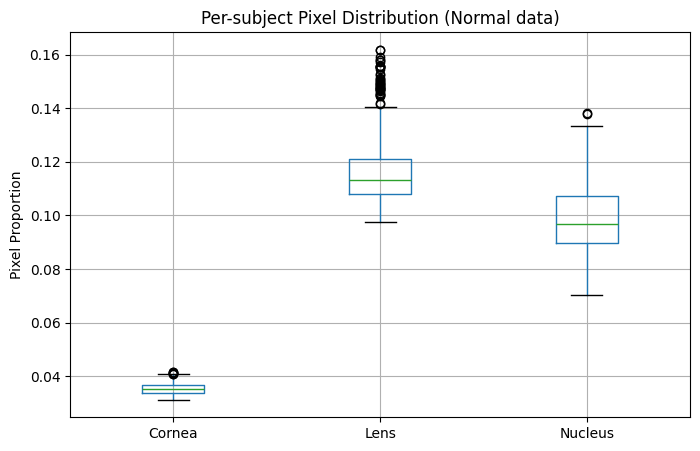

In [15]:
plt.figure(figsize=(8, 5))
# normal_counts[['Cornea', 'Lens', 'Nucleus']].boxplot()
# fuzzy_counts[['Cornea','Lens','Nucleus']].boxplot()
ax = plt.gca()
# normal_counts[['Cornea','Lens','Nucleus']].boxplot(ax=ax)
normal_dist[['Cornea','Lens','Nucleus']].boxplot(ax=ax)
plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution (Normal data)")
plt.show()

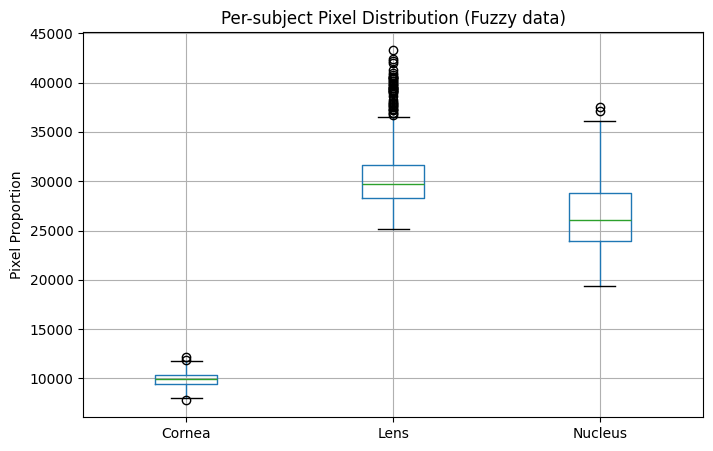

In [16]:
plt.figure(figsize=(8, 5))
# normal_counts[['Cornea', 'Lens', 'Nucleus']].boxplot()
# fuzzy_counts[['Cornea','Lens','Nucleus']].boxplot()
ax = plt.gca()
# normal_counts[['Cornea','Lens','Nucleus']].boxplot(ax=ax)
fuzzy_counts[['Cornea','Lens','Nucleus']].boxplot(ax=ax)
plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution (Fuzzy data)")
plt.show()

C:\Users\usman\AppData\Local\Temp\ipykernel_34176\1594244774.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


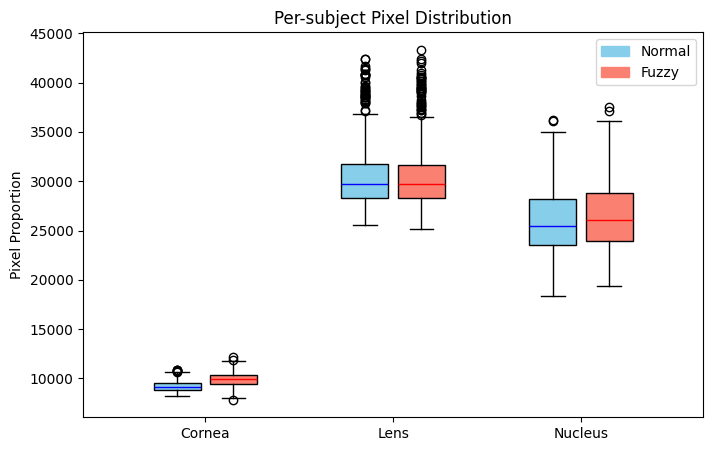

In [17]:
import matplotlib.pyplot as plt

classes = ['Cornea', 'Lens', 'Nucleus']
x = np.arange(len(classes))  # positions for boxplots

plt.figure(figsize=(8,5))

# Boxplot for normal_counts
plt.boxplot(
    [normal_counts[c] for c in classes], 
    positions=x-0.15,  # shift left
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='blue'),
    labels=classes
)

# Boxplot for fuzzy_counts
plt.boxplot(
    [fuzzy_counts[c] for c in classes], 
    positions=x+0.15,  # shift right
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor='salmon'),
    medianprops=dict(color='red')
)

plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution")
plt.xticks(x, classes)
plt.legend([plt.Rectangle((0,0),1,1,color='skyblue'),
            plt.Rectangle((0,0),1,1,color='salmon')],
           ['Normal', 'Fuzzy'])
plt.show()


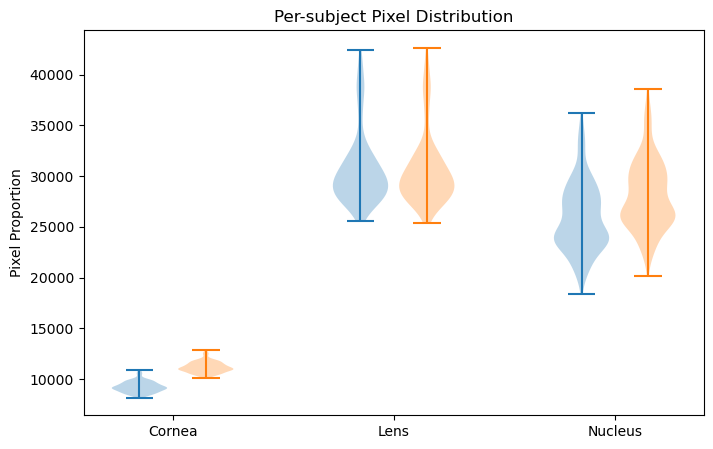

In [13]:
plt.figure(figsize=(8,5))
plt.violinplot([normal_counts[c] for c in classes], positions=x-0.15, widths=0.25)
plt.violinplot([fuzzy_counts[c] for c in classes], positions=x+0.15, widths=0.25)
plt.xticks(x, classes)
plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution")
plt.show()


C:\Users\usman\AppData\Local\Temp\ipykernel_34176\1755967368.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


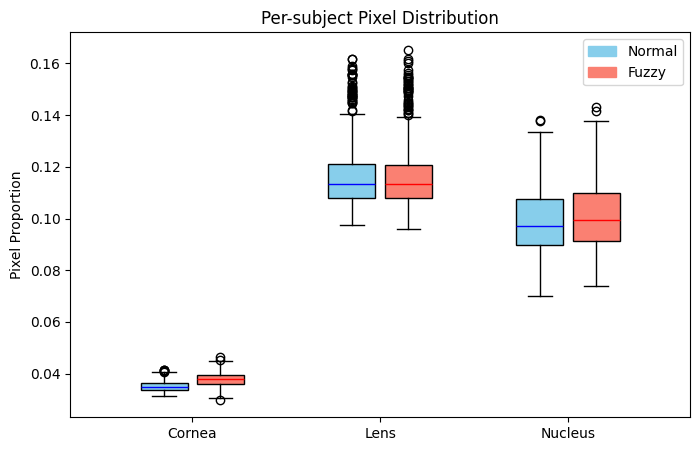

In [18]:
import matplotlib.pyplot as plt

classes = ['Cornea', 'Lens', 'Nucleus']
x = np.arange(len(classes))  # positions for boxplots

plt.figure(figsize=(8,5))

# Boxplot for normal_counts
plt.boxplot(
    [normal_dist[c] for c in classes], 
    positions=x-0.15,  # shift left
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='blue'),
    labels=classes
)

# Boxplot for fuzzy_counts
plt.boxplot(
    [fuzzy_dist[c] for c in classes], 
    positions=x+0.15,  # shift right
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor='salmon'),
    medianprops=dict(color='red')
)

plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution")
plt.xticks(x, classes)
plt.legend([plt.Rectangle((0,0),1,1,color='skyblue'),
            plt.Rectangle((0,0),1,1,color='salmon')],
           ['Normal', 'Fuzzy'])
plt.show()


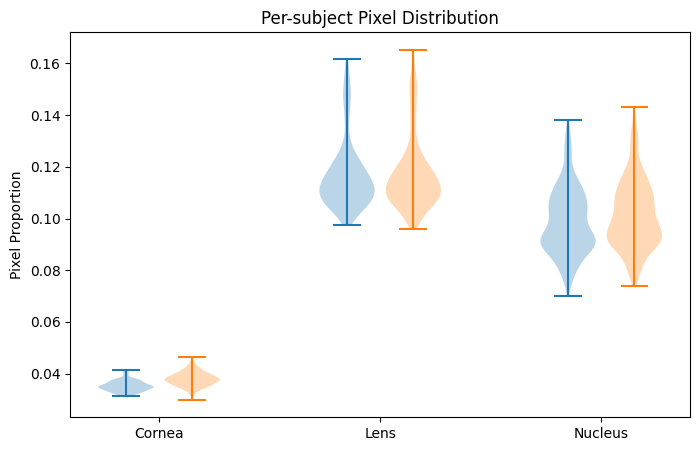

In [19]:
plt.figure(figsize=(8,5))
plt.violinplot([normal_dist[c] for c in classes], positions=x-0.15, widths=0.25)
plt.violinplot([fuzzy_dist[c] for c in classes], positions=x+0.15, widths=0.25)
plt.xticks(x, classes)
plt.ylabel("Pixel Proportion")
plt.title("Per-subject Pixel Distribution")
plt.show()


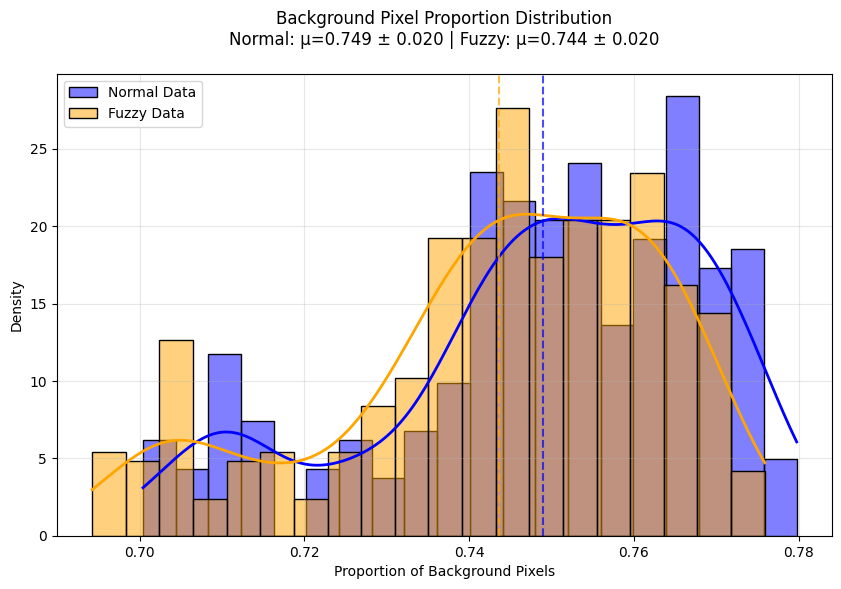

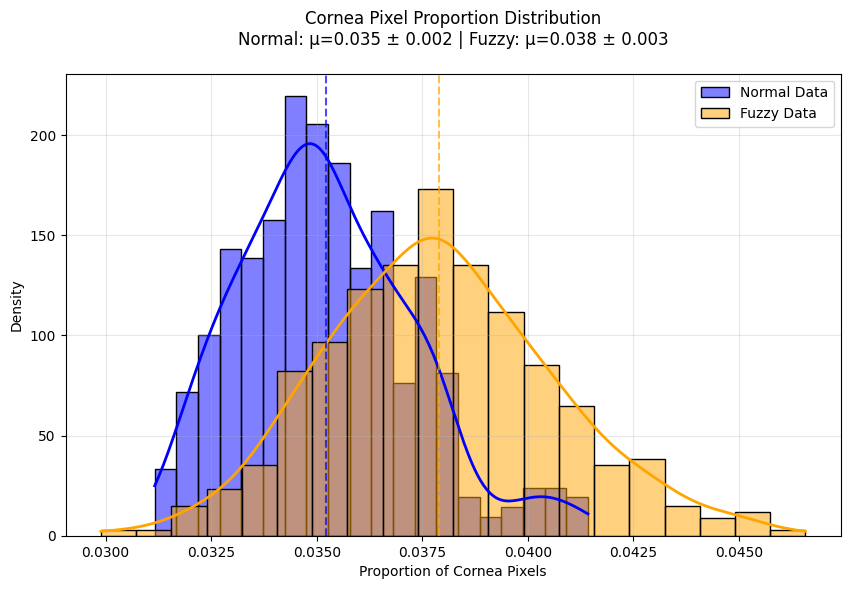

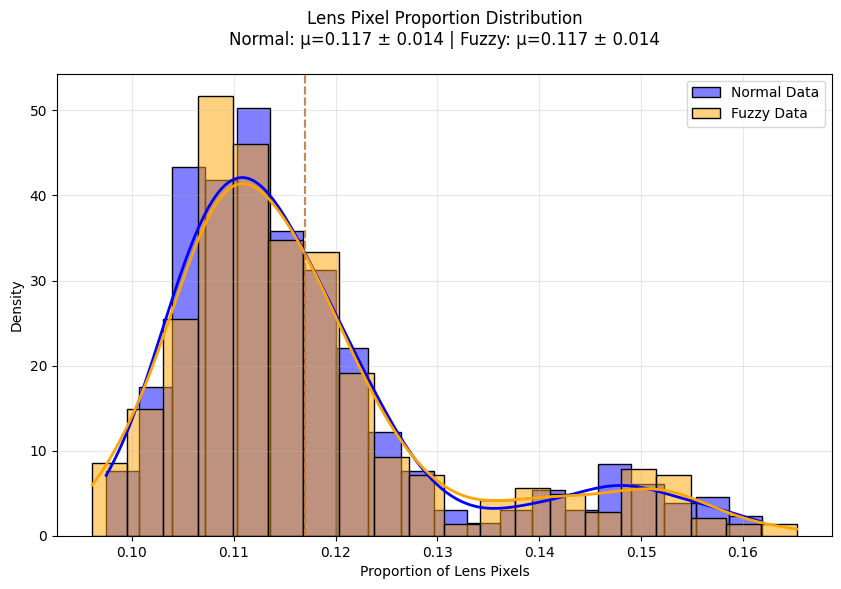

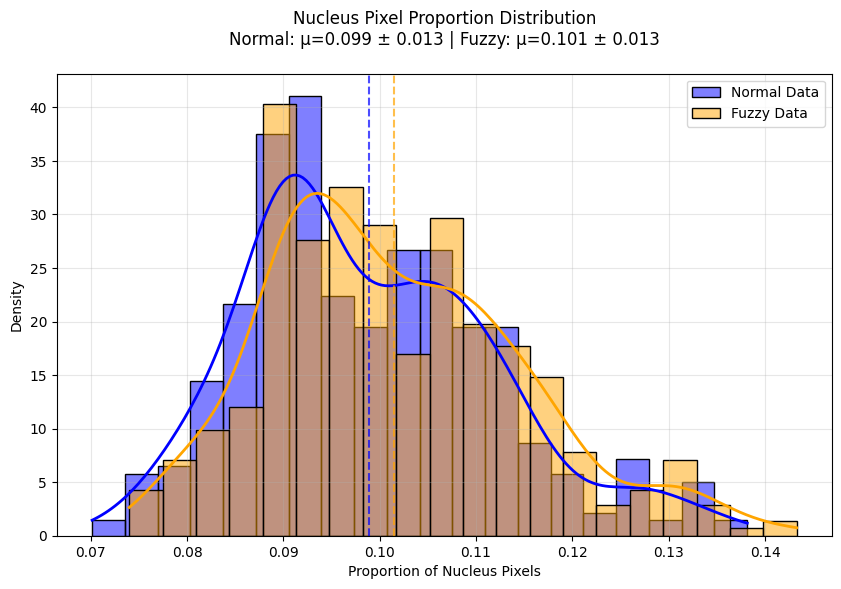

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

class_names = ['Background', 'Cornea', 'Lens', 'Nucleus']

for class_name in class_names:
    plt.figure(figsize=(10, 6))
    
    # Use seaborn for better-looking KDE and histograms
    sns.histplot(normal_dist[class_name], bins=20, alpha=0.5, label='Normal Data',
                 color='blue', stat='density', kde=True, line_kws={'linewidth': 2})
    sns.histplot(fuzzy_dist[class_name], bins=20, alpha=0.5, label='Fuzzy Data',
                 color='orange', stat='density', kde=True, line_kws={'linewidth': 2})
    
    # Or alternatively: pure KDE without histogram bars
    # sns.kdeplot(normal_dist[class_name], label='Normal Data', color='blue', linewidth=2)
    # sns.kdeplot(fuzzy_dist[class_name], label='Fuzzy Data', color='orange', linewidth=2)
    
    # Add mean lines
    plt.axvline(normal_dist[class_name].mean(), color='blue', linestyle='--', alpha=0.7)
    plt.axvline(fuzzy_dist[class_name].mean(), color='orange', linestyle='--', alpha=0.7)
    
    # Statistical test (example: Kolmogorov-Smirnov)
    ks_stat, p_value = stats.ks_2samp(normal_dist[class_name], fuzzy_dist[class_name])
    
    plt.title(f'{class_name} Pixel Proportion Distribution\n'
              f'Normal: μ={normal_dist[class_name].mean():.3f} ± {normal_dist[class_name].std():.3f} '
              f'| Fuzzy: μ={fuzzy_dist[class_name].mean():.3f} ± {fuzzy_dist[class_name].std():.3f}\n'
            #   f'KS test p-value: {p_value:.3f}'
            )
    
    plt.xlabel(f'Proportion of {class_name} Pixels')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()